## Data preprocessing and Random forest / XG boost

In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(r'E:\competition\COmsic Classifier IIT Roorkie\Cosmic-Classifier\data\thermoracleTrain.csv')
df = df.dropna(subset=['Prediction'])

In [4]:
df.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
7124,-1.681429,1.191522,-1.117887,2.016421,-1.402843,0.010470,-1.629714,NaN,Category_9,1.131391,4.0
47911,0.474254,-0.002334,3.039438,2.127570,2.129051,-3.590311,1.677139,Category_11,Category_9,-0.501133,6.0
16965,0.305605,-1.910953,2.218698,-3.324390,2.755752,1.300698,0.830526,Category_4,Category_7,0.624814,8.0
3716,NaN,1.879126,0.257894,1.460888,NaN,-0.898455,-2.772917,Category_14,Category_11,0.714640,4.0
3096,-0.010197,NaN,-0.176700,1.726323,0.264586,-0.569943,0.669109,Category_5,Category_7,-1.646907,6.0


In [5]:
df.isnull().sum()

Atmospheric Density              2842
Surface Temperature              2896
Gravity                          2826
Water Content                    2936
Mineral Abundance                2784
Orbital Period                   2855
Proximity to Star                2786
Magnetic Field Strength          2941
Radiation Levels                 2859
Atmospheric Composition Index    2795
Prediction                          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56961 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Atmospheric Density            54119 non-null  float64
 1   Surface Temperature            54065 non-null  float64
 2   Gravity                        54135 non-null  float64
 3   Water Content                  54025 non-null  float64
 4   Mineral Abundance              54177 non-null  float64
 5   Orbital Period                 54106 non-null  float64
 6   Proximity to Star              54175 non-null  float64
 7   Magnetic Field Strength        54020 non-null  object 
 8   Radiation Levels               54102 non-null  object 
 9   Atmospheric Composition Index  54166 non-null  float64
 10  Prediction                     56961 non-null  float64
dtypes: float64(9), object(2)
memory usage: 5.2+ MB


In [7]:
df['Prediction'].isna().sum()

0

In [9]:
df = pd.get_dummies(df , columns = ['Magnetic Field Strength' , 'Radiation Levels'])

In [10]:

for col in ["Atmospheric Density", "Gravity"]:
    median_value = df[df[col] > 0][col].median()
    df[col] = df[col].apply(lambda x: median_value if x < 0 else x)

In [11]:

columns_to_fix = ["Surface Temperature", "Orbital Period", "Proximity to Star","Water Content","Mineral Abundance"]


df[columns_to_fix] = df[columns_to_fix].abs()

In [12]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Prediction'])
y = df['Prediction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
impute_columns = ['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',

'Surface Temperature']

In [10]:

# df["Water Content"] = df["Water Content"].apply(lambda x: max(x, 0))
# df["Mineral Abundance"] = df["Mineral Abundance"].apply(lambda x: max(x, 0))

In [15]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10),
    max_iter=5,
    random_state=36
)
X_train[impute_columns] = imputer.fit_transform(X_train[impute_columns])
X_test[impute_columns] = imputer.transform(X_test[impute_columns])

C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [17]:
X_test.isnull().sum()

Atmospheric Density                    0
Surface Temperature                    0
Gravity                                0
Water Content                          0
Mineral Abundance                      0
Orbital Period                         0
Proximity to Star                      0
Atmospheric Composition Index          0
Magnetic Field Strength_Category_1     0
Magnetic Field Strength_Category_10    0
Magnetic Field Strength_Category_11    0
Magnetic Field Strength_Category_12    0
Magnetic Field Strength_Category_13    0
Magnetic Field Strength_Category_14    0
Magnetic Field Strength_Category_15    0
Magnetic Field Strength_Category_16    0
Magnetic Field Strength_Category_17    0
Magnetic Field Strength_Category_18    0
Magnetic Field Strength_Category_19    0
Magnetic Field Strength_Category_2     0
Magnetic Field Strength_Category_20    0
Magnetic Field Strength_Category_3     0
Magnetic Field Strength_Category_4     0
Magnetic Field Strength_Category_5     0
Magnetic Field S

In [25]:

import pandas as pd
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in numeric_cols:
    # Fit transformer on non-null training values
    non_null_train = ~X_train[col].isna()
    transformer = PowerTransformer(method='yeo-johnson')
    train_vals = X_train.loc[non_null_train, col].values.reshape(-1, 1)
    train_transformed = transformer.fit_transform(train_vals).flatten()
    X_train.loc[non_null_train, f"{col}_power"] = train_transformed

    print(f"Lambda for {col}: {transformer.lambdas_[0]:.4f}")

    # Transform test data using the same transformer
    non_null_test = ~X_test[col].isna()
    test_vals = X_test.loc[non_null_test, col].values.reshape(-1, 1)
    test_transformed = transformer.transform(test_vals).flatten()
    X_test.loc[non_null_test, f"{col}_power"] = test_transformed

    print(f"Test Lambda for {col}: {transformer.lambdas_[0]:.4f}")

X_train = X_train.drop(columns=numeric_cols)
X_test = X_test.drop(columns=numeric_cols)

Lambda for Atmospheric Density: -0.2788
Test Lambda for Atmospheric Density: -0.2788
Lambda for Surface Temperature: 0.1893
Test Lambda for Surface Temperature: 0.1893
Lambda for Gravity: -0.0354
Test Lambda for Gravity: -0.0354
Lambda for Water Content: -0.1074
Test Lambda for Water Content: -0.1074
Lambda for Mineral Abundance: -0.1781
Test Lambda for Mineral Abundance: -0.1781
Lambda for Orbital Period: -0.1032
Test Lambda for Orbital Period: -0.1032
Lambda for Proximity to Star: -0.2098
Test Lambda for Proximity to Star: -0.2098
Lambda for Atmospheric Composition Index: 1.1235
Test Lambda for Atmospheric Composition Index: 1.1235
Lambda for Atmospheric Density_power: 1.0188
Test Lambda for Atmospheric Density_power: 1.0188
Lambda for Surface Temperature_power: 1.0261
Test Lambda for Surface Temperature_power: 1.0261
Lambda for Gravity_power: 1.0084
Test Lambda for Gravity_power: 1.0084
Lambda for Water Content_power: 1.0013
Test Lambda for Water Content_power: 1.0013
Lambda for Min

In [26]:
X_train.sample(5)

,Magnetic Field Strength_Category_1,Magnetic Field Strength_Category_10,Magnetic Field Strength_Category_11,Magnetic Field Strength_Category_12,Magnetic Field Strength_Category_13,Magnetic Field Strength_Category_14,Magnetic Field Strength_Category_15,Magnetic Field Strength_Category_16,Magnetic Field Strength_Category_17,Magnetic Field Strength_Category_18,...,Radiation Levels_Category_8,Radiation Levels_Category_9,Atmospheric Density_power_power,Surface Temperature_power_power,Gravity_power_power,Water Content_power_power,Mineral Abundance_power_power,Orbital Period_power_power,Proximity to Star_power_power,Atmospheric Composition Index_power_power
886,False,True,False,False,False,False,False,False,False,False,...,False,False,0.370129,1.097175,0.000081,0.105104,-1.504982,-1.166712,-0.491613,-1.371830
12856,False,False,False,False,False,False,False,False,False,False,...,False,False,-0.864932,-0.481782,0.000081,-0.596624,0.174437,-0.937957,0.925169,-1.249599
13367,False,False,False,False,False,False,False,False,False,False,...,True,False,-1.074516,1.832009,-0.305570,0.539568,0.046592,-0.073750,-0.021304,-0.376407
57483,False,False,False,False,False,False,False,False,False,False,...,False,True,-0.007238,1.533987,-1.044734,0.403284,-0.088362,0.638625,-1.261016,-0.414571
27907,False,False,False,False,False,False,False,False,False,False,...,False,False,0.546786,-0.868098,0.070319,0.763414,1.867877,-0.535196,-1.280788,0.311280


In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from xgboost import XGBClassifier


# X = df.drop(columns=['Prediction'])
# y = df['Prediction']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [28]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6857


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.85      0.82      1112
         1.0       0.83      0.93      0.88      1315
         2.0       0.64      0.65      0.64      1127
         3.0       0.61      0.61      0.61      1172
         4.0       0.62      0.57      0.59      1109
         5.0       0.61      0.52      0.56      1037
         6.0       0.74      0.80      0.77      1105
         7.0       0.74      0.68      0.71      1189
         8.0       0.60      0.57      0.58      1101
         9.0       0.60      0.64      0.62      1126

    accuracy                           0.69     11393
   macro avg       0.68      0.68      0.68     11393
weighted avg       0.68      0.69      0.68     11393



In [32]:
modelxgb = XGBClassifier(n_estimators=1000, random_state=42)
modelxgb.fit(X_train, y_train)

y_predxgb = modelxgb.predict(X_test)

accuracy = accuracy_score(y_test, y_predxgb)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6935


C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [00:54:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [00:54:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-merror:0.47351	validation_0-mlogloss:1.92123	validation_1-merror:0.49092	validation_1-mlogloss:1.93643
[1]	validation_0-merror:0.44220	validation_0-mlogloss:1.74289	validation_1-merror:0.46344	validation_1-mlogloss:1.76857
[2]	validation_0-merror:0.42223	validation_0-mlogloss:1.61809	validation_1-merror:0.44712	validation_1-mlogloss:1.65124
[3]	validation_0-merror:0.41185	validation_0-mlogloss:1.52493	validation_1-merror:0.43509	validation_1-mlogloss:1.56572
[4]	validation_0-merror:0.40019	validation_0-mlogloss:1.45213	validation_1-merror:0.42737	validation_1-mlogloss:1.49963
[5]	validation_0-merror:0.39030	validation_0-mlogloss:1.39020	validation_1-merror:0.42070	validation_1-mlogloss:1.44394
[6]	validation_0-merror:0.38490	validation_0-mlogloss:1.33953	validation_1-merror:0.41403	validation_1-mlogloss:1.39814
[7]	validation_0-merror:0.37766	validation_0-mlogloss:1.29810	validation_1-merror:0.40990	validation_1-mlogloss:1.36235
[8]	validation_0-merror:0.37037	validati

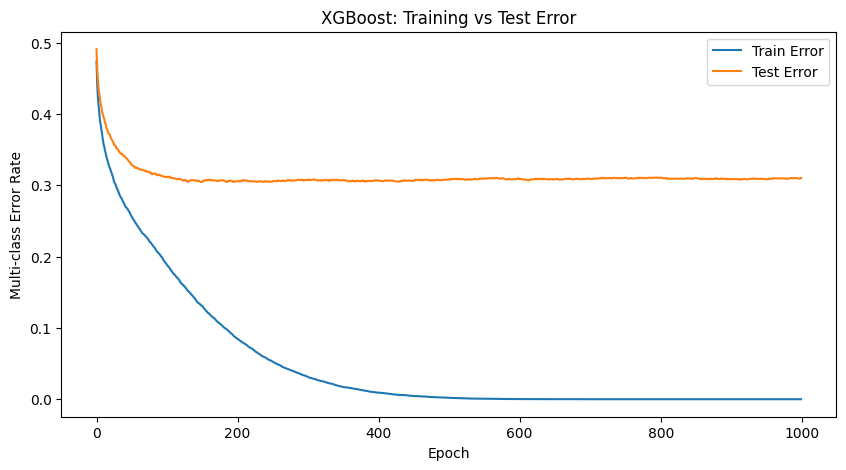

In [35]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml



# Define evaluation set
eval_set = [(X_train, y_train), (X_test, y_test)]

# Train the model
modelxgb = xgb.XGBClassifier(
    n_estimators=1000,  # Increase the number of boosting rounds
    eval_metric=['merror', 'mlogloss'],
    use_label_encoder=False,
    objective='multi:softmax',
    num_class=10,
    tree_method='gpu_hist'  # Enable GPU acceleration
)

modelxgb.fit(
    X_train, 
    y_train,
    eval_set=eval_set,
    verbose=True
)

# Retrieve evaluation results
results = modelxgb.evals_result()
epochs = len(results['validation_0']['merror'])  # Changed 'error' to 'merror'
x_axis = range(epochs)

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['merror'], label='Train Error')
plt.plot(x_axis, results['validation_1']['merror'], label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Multi-class Error Rate')
plt.title('XGBoost: Training vs Test Error')
plt.legend()
plt.show()

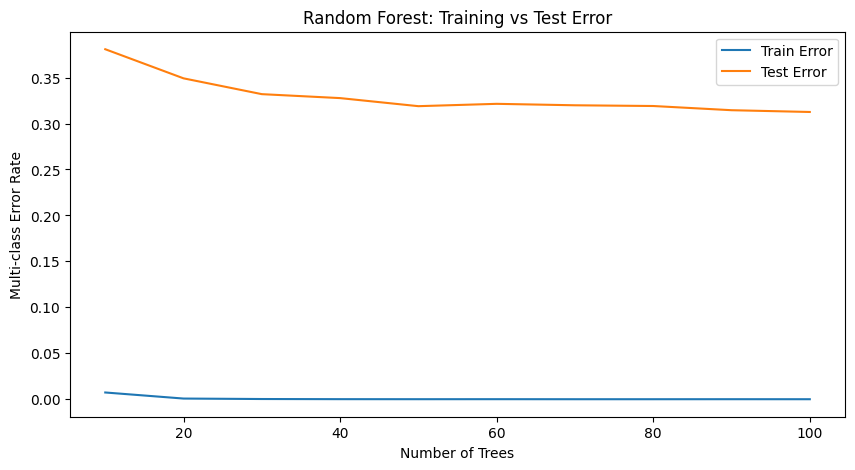

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

# Train the model
model = RandomForestClassifier(
    n_estimators=500,
    criterion='gini',
    max_depth=None,
    n_jobs=-1  # Use all CPU cores
)

model.fit(X_train, y_train)

# Since RandomForest doesn't have built-in evaluation tracking like XGBoost,
# we'll simulate it by tracking error across different forest sizes
train_errors = []
test_errors = []
logloss_train = []
logloss_test = []

# Evaluate incrementally (simulating epochs)
n_trees = range(10, 101, 10)  # 10, 20, ..., 100 trees
for n in n_trees:
    # Create a forest with n trees
    temp_model = RandomForestClassifier(n_estimators=n, n_jobs=-1)
    temp_model.fit(X_train, y_train)
    
    # Get predictions
    y_pred_train = temp_model.predict(X_train)
    y_pred_test = temp_model.predict(X_test)
    
    # Calculate error rates (1 - accuracy)
    train_error = 1 - accuracy_score(y_train, y_pred_train)
    test_error = 1 - accuracy_score(y_test, y_pred_test)
    
    # Get probabilities for log loss
    y_prob_train = temp_model.predict_proba(X_train)
    y_prob_test = temp_model.predict_proba(X_test)
    
    train_errors.append(train_error)
    test_errors.append(test_error)
    logloss_train.append(log_loss(y_train, y_prob_train))
    logloss_test.append(log_loss(y_test, y_prob_test))

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(n_trees, train_errors, label='Train Error')
plt.plot(n_trees, test_errors, label='Test Error')
plt.xlabel('Number of Trees')
plt.ylabel('Multi-class Error Rate')
plt.title('Random Forest: Training vs Test Error')
plt.legend()
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization

def rf_csv(max_depth, n_estimators, min_samples_split, min_samples_leaf, max_features):
    params = {
        'max_depth': int(max_depth),
        'n_estimators': int(n_estimators),
        'min_samples_split': int(min_samples_split),
        'min_samples_leaf': int(min_samples_leaf),
        'max_features': max_features,
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv_results = cross_val_score(
        RandomForestClassifier(**params),
        X_train, y_train,
        scoring='accuracy',
        cv=5
    )
    return cv_results.mean()





In [26]:
pbounds = {
    'max_depth': (3, 12),
    'n_estimators': (100, 1000),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 5),
    'max_features': (0.1, 1.0)
}

optimizer = BayesianOptimization(
    f=rf_csv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

In [ ]:

optimizer.maximize(
    init_points=10,
    n_iter=15
)

print(optimizer.max)

|   iter    |  target   | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------
| 1         | 1.0       | 6.371     | 0.9556    | 3.928     | 6.789     | 240.4     |
| 2         | 0.7478    | 4.404     | 0.1523    | 4.465     | 6.809     | 737.3     |
| 3         | 0.9652    | 3.185     | 0.9729    | 4.33      | 3.699     | 263.6     |
| 4         | 0.881     | 4.651     | 0.3738    | 3.099     | 5.456     | 362.1     |
| 5         | 0.9439    | 8.507     | 0.2255    | 2.169     | 4.931     | 510.5     |
| 6         | 0.9861    | 10.07     | 0.2797    | 3.057     | 6.739     | 141.8     |
| 7         | 0.9567    | 8.468     | 0.2535    | 1.26      | 9.591     | 969.1     |
